# **1. Hotelling’s $T^2$ Test for a Mean Vector**

In [97]:
X <- matrix(
  c(2, 12,
    8, 9,
    6, 9,
    8, 10),
  nrow = 4,
  byrow = TRUE
)

print(X)

     [,1] [,2]
[1,]    2   12
[2,]    8    9
[3,]    6    9
[4,]    8   10


## **1.a**

In [98]:
n <- nrow(X)
p <- ncol(X)

xbar <- colMeans(X)
cat("The sample mean vector is:")
xbar

S <- cov(X)

mu0 <- c(7, 11)

d <- xbar - mu0

T2 <- n * t(d) %*% solve(S) %*% d

cat("Hotelling's T^2 is:")
T2

The sample mean vector is:

[1]  6 10

Hotelling's T^2 is:

13.63636


## **1.b**

Under the null hypothesis, $T^2$ transforms into an $F$-distribution where:

$$T^{2} \sim \frac{p(n-1)}{n-p} F_{p, n-p}$$

Substituting $n=4$ and $p=2$, we get

:$$T^{2} \sim \frac{2(3)}{2} F_{2, 2} = 3 F_{2, 2}$$

## **1.c**

In [99]:
crit_F <- qf(0.95, p, n - p)
crit_T2 <- (p * (n - 1) / (n - p)) * crit_F

cat("Critical T^2 value is:")
crit_T2

Critical T^2 value is:

[1] 57

Since Critical T^2 value is greater than T^2 value, this means we fail to reject the null hypothesis. This means that there is not enough evidence to conclude that the population mean vector differs from $\mu^{\prime} = [7, 11]$ at the 5% significance level.

This means that the sample aligns with the theorized mean vector $\mu^{\prime} = [7, 11]$ .

# **2. Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements**

In [100]:
n <- 61
p <- 6

xbar <- c(
  Weight = 95.52,
  Body_Length = 164.38,
  Neck = 55.69,
  Girth = 93.39,
  Head_Length = 17.98,
  Head_Width = 31.13
)

xbar

S <- matrix(
  c(
    3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37,
    1343.97, 721.91, 324.25, 537.35, 80.17, 117.73,
    731.54, 324.25, 179.28, 281.17, 39.15, 56.80,
    1175.50, 537.35, 281.17, 474.98, 63.73, 94.85,
    162.68, 80.17, 39.15, 63.73, 9.95, 13.88,
    238.37, 117.73, 56.80, 94.85, 13.88, 21.26
  ),
  nrow = 6,
  byrow = TRUE
)

S

Weight Body_Length        Neck       Girth Head_Length  Head_Width 
      95.52      164.38       55.69       93.39       17.98       31.13

3266.46,1343.97,731.54,1175.50,162.68,238.37
1343.97,721.91,324.25,537.35,80.17,117.73
731.54,324.25,179.28,281.17,39.15,56.80
1175.50,537.35,281.17,474.98,63.73,94.85
162.68,80.17,39.15,63.73,9.95,13.88
238.37,117.73,56.80,94.85,13.88,21.26


## **2.a**

In [101]:
chi_val <- qchisq(0.95, df = p)
margin <- sqrt(
  chi_val * diag(S) / n
)

CI <- cbind(
  Lower = xbar - margin,
  Upper = xbar + margin
)

cat("95% Simultaneous Confidence Intervals for the six population mean
body measurements:\n")
CI

95% Simultaneous Confidence Intervals for the six population mean
body measurements:


,Lower,Upper
Weight,69.55347,121.48653
Body_Length,152.17278,176.58722
Neck,49.60667,61.77333
Girth,83.48823,103.29177
Head_Length,16.54687,19.41313
Head_Width,29.03513,33.22487


## **2.b**

In [102]:
install.packages("car")
library(car)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



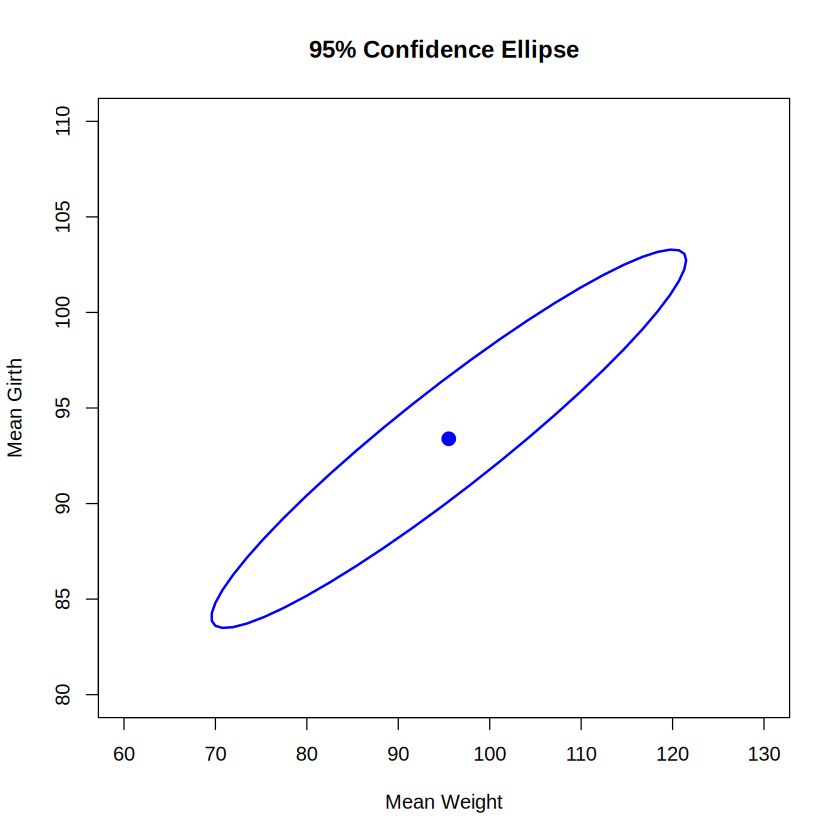

In [103]:
sub_S <- S[c(1,4), c(1,4)]
sub_xbar <- xbar[c(1,4)]

plot(0, 0, type="n", xlim=c(60, 130), ylim=c(80, 110),
     xlab="Mean Weight", ylab="Mean Girth", main="95% Confidence Ellipse")
ellipse(sub_xbar, sub_S/n, radius=sqrt(chi_val), col="blue")

The ellipse is centered at around (95.52,93.38), which is inline with the calculated mean for weight and girth respectively. The ellipse represents the probable combinations of the population mean vector for weight and girth simultaneously at the 95% confidence level.

## **2.c**

In [104]:
m <- 6

t_bonferroni <- qt(1 - 0.05/(2*m), df = n-1)
bonferroni_margin <- t_bonferroni * sqrt(diag(S)/n)
bonferroni_CI <- cbind(Lower = xbar - bonferroni_margin, Upper = xbar + bonferroni_margin)

cat("Bonferroni CIs for the six means in part (a):")
bonferroni_CI

Bonferroni CIs for the six means in part (a):

,Lower,Upper
Weight,75.55331,115.48669
Body_Length,154.99339,173.76661
Neck,51.01229,60.36771
Girth,85.77614,101.00386
Head_Length,16.87801,19.08199
Head_Width,29.51917,32.74083


## **2.d**

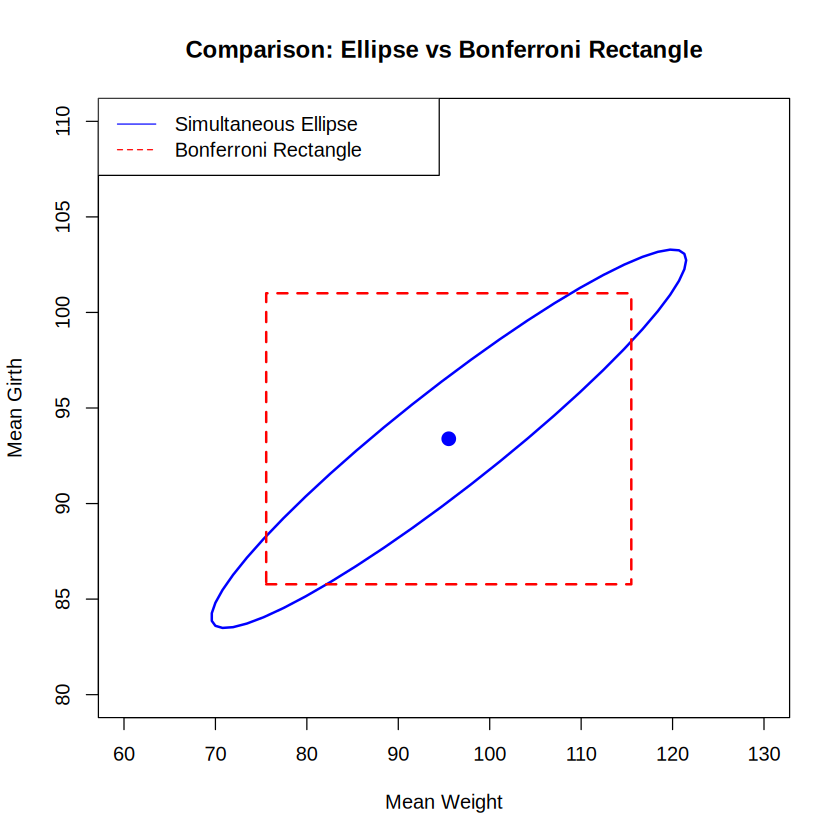

In [105]:
plot(0, 0, type="n", xlim=c(60, 130), ylim=c(80, 110),
     xlab="Mean Weight", ylab="Mean Girth",
     main="Comparison: Ellipse vs Bonferroni Rectangle")
ellipse(sub_xbar, sub_S/n, radius=sqrt(chi_val), col="blue")
rect(bonferroni_CI[1,1], bonferroni_CI[4,1], bonferroni_CI[1,2], bonferroni_CI[4,2], border="red", lty=2, lwd=2)
legend("topleft", legend=c("Simultaneous Ellipse", "Bonferroni Rectangle"),
       col=c("blue", "red"), lty=c(1, 2))

The Bonferroni confidence rectangle was constructed using the separate Bonferroni confidence intervals for mean weight and mean girth. Meanwhile the ellipse uses the calculated covariance, which considers the weight and girth together. This means that the Bonferroni confidence rectangle and simulatenous confidence ellipse have different ways of calculating the joint uncertainty in the mean weight and mean girth.

For the graph while there is some overlap, there are noticeable differences. To start, the ellipse is longer compared to the rectangle, both of its x-axis and y-axis extend past the rectangle. Meanwhile, the upper-left and bottom-right corners of the rectangle has values which the ellipse doesn't. Finally, the ellipse is tilted upward, which shows the positive correlation between the mean weight and mean girth. This relationship wasn't captured by the Bonferroni confidence rectangle since the rectangle calculated the intervals separately compared to the ellipse which included the covariance.

## **2.e**

In [106]:
m_new <- 7
t_bonferroni_new <- qt(1 - 0.05/(2*m_new), df = n-1)

diff_mean <- xbar[6] - xbar[5]
diff_var <- S[6,6] + S[5,5] - 2*S[5,6]
diff_se <- sqrt(diff_var / n)
diff_CI <- c(diff_mean - t_bonferroni_new * diff_se, diff_mean + t_bonferroni_new * diff_se)

cat("Bonferroni CI for Difference (Head Width - Length):")
diff_CI

Bonferroni CI for Difference (Head Width - Length):

Head_Width Head_Width 
  12.48757   13.81243

Population mean Head_Length is 17.98 and population mean Head_Width is 31.13. The estimated difference between them is is 31.13-17.98 = 13.15. Using m = 7, the 95% Bonferroni CI is (12.4875653260697, 13.8124346739303). This means that we are 95% confident that the that the difference between the population mean head width and population mean head length is between approximately 12.49 cm and 13.81 cm. Since this interval is positive, the population population mean head width is estimated to be greater than the population mean head length.


# **3**

In [107]:
x1 <- c(0.48, 40.53, 2.19, 0.55, 0.74, 0.66, 93.00, 0.37, 0.22)
x2 <- c(12.57, 73.68, 11.13, 20.03, 20.29, 0.78, 4.64, 0.43, 1.08)

peru_data <- data.frame(
  cr = x1,
  st = x2
)

n <- nrow(peru_data)
p <- ncol(peru_data)
xbar <- colMeans(peru_data)
S <- cov(peru_data)

peru_data
cat("Column Means (X-bar):\n")
xbar

cat("Covariance (S):\n")
S

cr,st
<dbl>,<dbl>
0.48,12.57
40.53,73.68
2.19,11.13
0.55,20.03
0.74,20.29
0.66,0.78
93.00,4.64
0.37,0.43
0.22,1.08


Column Means (X-bar):


cr       st 
15.41556 16.07000

Covariance (S):


,cr,st
cr,1019.9280,155.6962
st,155.6962,527.8493


## **3.a**

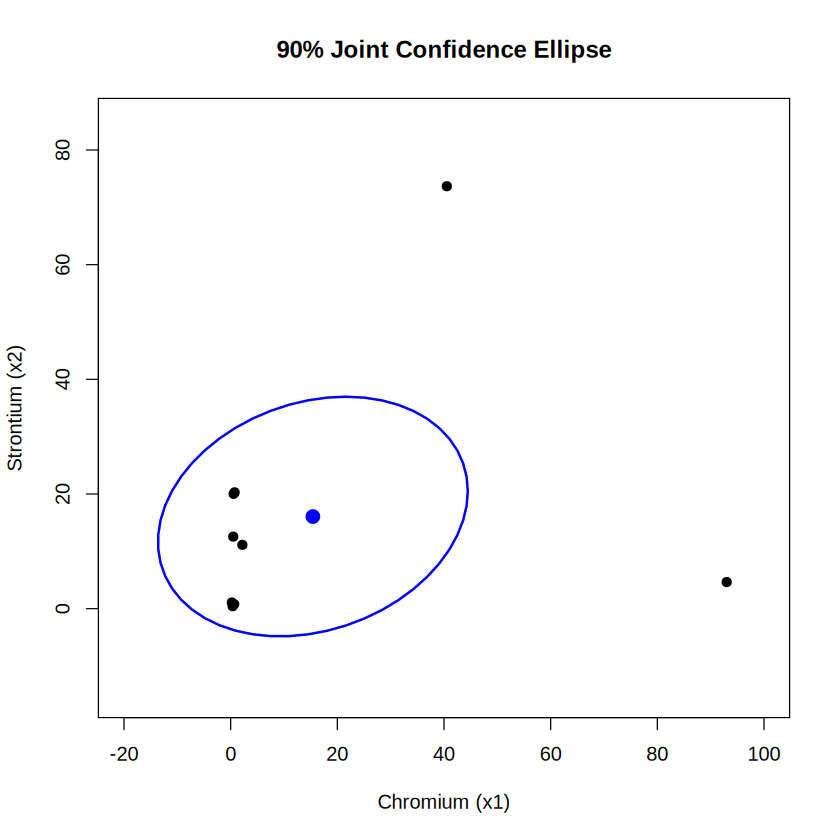

In [108]:
F_crit <- qf(0.90, p, n - p)
crit_val<- ((n - 1) * p / (n - p)) * F_crit

plot(peru_data$cr, peru_data$st,
     xlim=c(-20, 100),ylim=c(-15, 85),
     xlab="Chromium (x1)", ylab="Strontium (x2)",
     pch=19, main="90% Joint Confidence Ellipse")

ellipse(xbar, S/n, radius=sqrt(crit_val), col="blue")

## **3.b**

In [109]:
margin <- sqrt(crit_val) * sqrt(diag(S)/n)
CI <- cbind(Lower = xbar - margin, Upper = xbar + margin)
cat("Simultaneous 90% CIs:")
CI

test_mu <- c(0.30, 10)
T2_test <- n * t(xbar - test_mu) %*% solve(S) %*% (xbar - test_mu)
cat("T2 for [.30, 10]:", T2_test, "\n")
cat("Critical Value:", crit_val, "\n")

Simultaneous 90% CIs:

,Lower,Upper
cr,-13.632217,44.46333
st,-4.826957,36.96696


T2 for [.30, 10]: 2.268901 
Critical Value: 7.445582 


The simultaneous 90% confidence interval for strontium is (-4.826957,36.96696). Since 10 is inside that interval, this means that the data does not provide evidence against a population mean strontium level of 10 ppm.

For the proposed population mean vector [0.30,10]', T^2 is calculated to be 2.268901. Since the critical value is 7.445582, this means T^2 is well below the critical value. Thus [0.30,10]' is considered to be a plausible value for the population mean vector based on the 90% confidence region.

## **3.c**

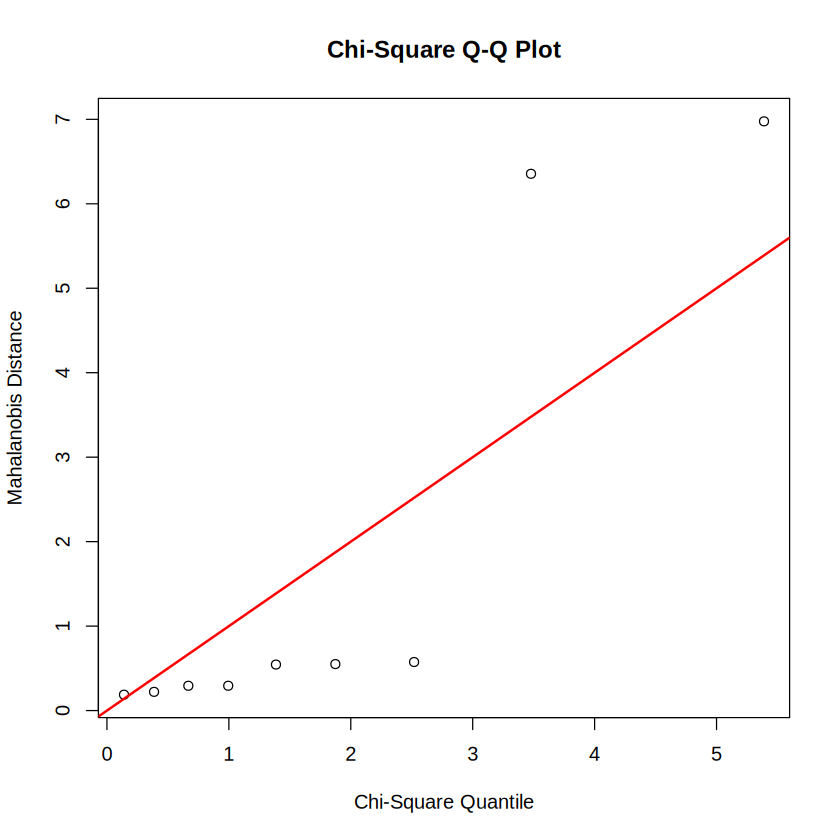

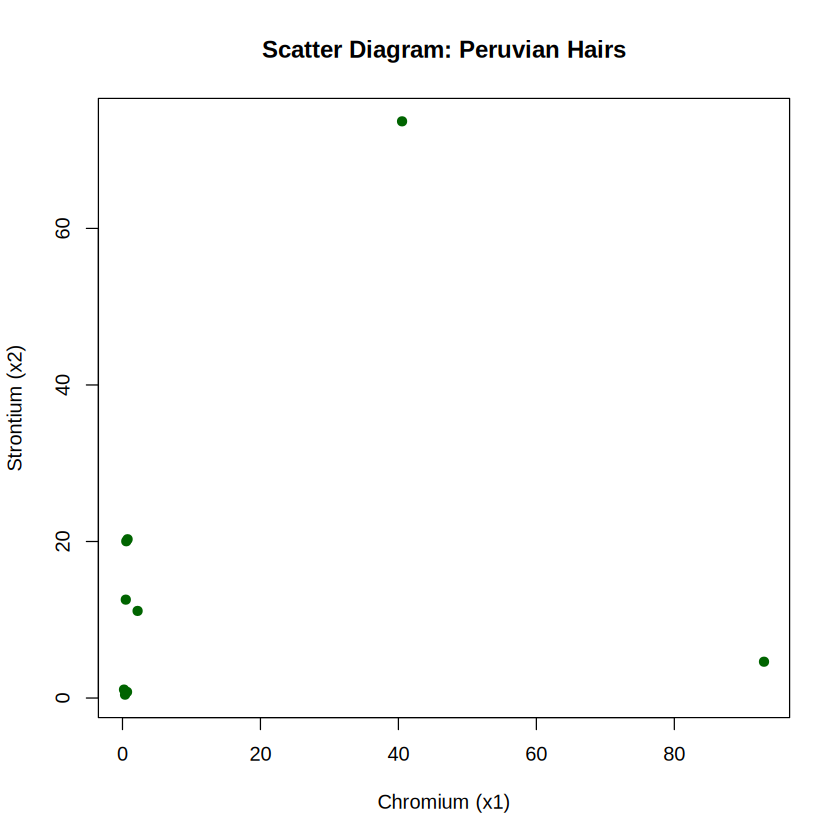

In [110]:
d2 <- mahalanobis(peru_data, xbar, S)
qqplot(qchisq(ppoints(n), df = p), d2,
       main = "Chi-Square Q-Q Plot", xlab="Chi-Square Quantile", ylab="Mahalanobis Distance")
abline(a = 0, b = 1, col="red", lwd=2)

plot(peru_data$cr, peru_data$st,
     main="Scatter Diagram: Peruvian Hairs",
     xlab="Chromium (x1)", ylab="Strontium (x2)", pch=19, col="darkgreen")

Chi-Square Q-Q Plot: For a bivariate normal distribution, points should closely follow the red reference line. However, in the graph produced, the points are mostly below the reference line while the rightmost points have a large jump in value, meaning this is a heavy-tailed, non-normal distribution.   

Scatter Diagram: For a bivariate normal distribution, points should produce a roughly cohesive, elliptical "cloud." However, in the graph produced, the data does not follow this shape. Majority  of the points are tightly clustered near the origin (very low Chromium and Strontium), while distinct, extreme outliers exist far from the cluster in the origin. This confirms the result from the Q-Q Plot.

Since the data are shown to NOT be bivariate normally distributed, this assumption was violated. This means that the theoretical Hotelling's (T^2) distribution, which was used to create the confidence ellipse and simultaneous confidence intervals, may not be accurate or reliable. Thus the results from part (a) and (b) may be inaccurate and lead to unreliable inferences and analysis.

## **3.d**

In [111]:
outlier <- which.max(d2)
clean_data <- peru_data[-outlier, ]
n_new <- nrow(clean_data)
xbar_new <- colMeans(clean_data)
S_new <- cov(clean_data)

crit_val_new <- ((n_new - 1) * p / (n_new - p)) * qf(0.90, p, n_new - p)
test_mu_new <- c(0.30, 10)
T2_test_new <- n_new * t(xbar_new - test_mu_c) %*% solve(S_new) %*% (xbar_new - test_mu_new)
cat("After outlier removal, New T2 for [.30, 10]:", T2_test_new, "\n")
cat("New Critical Value:", crit_val_new, "\n")

After outlier removal, New T2 for [.30, 10]: 1.381806 
New Critical Value: 8.081043 


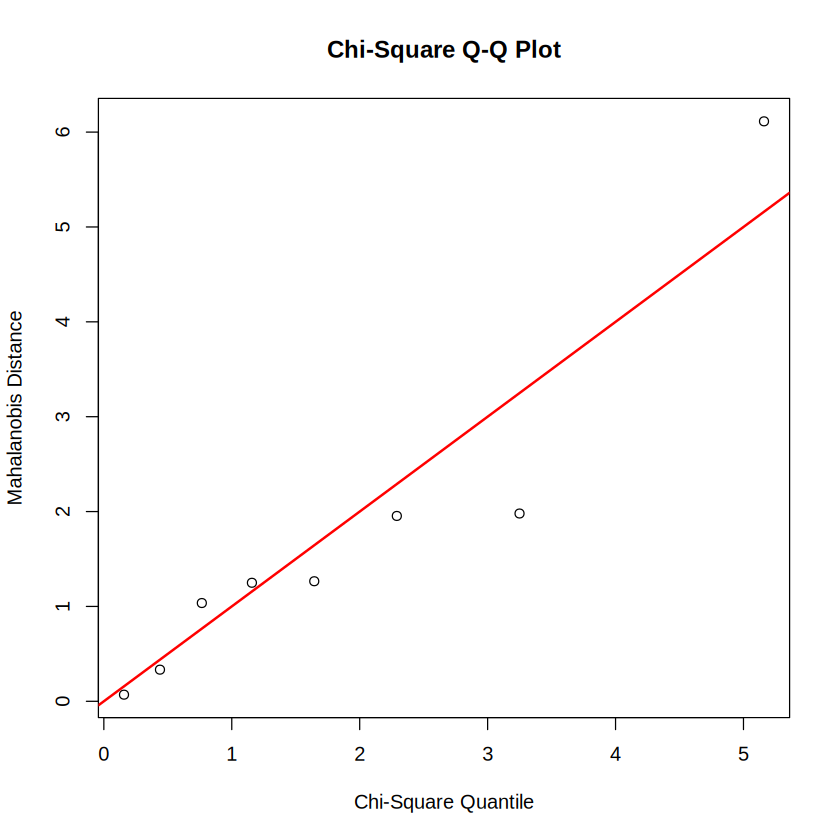

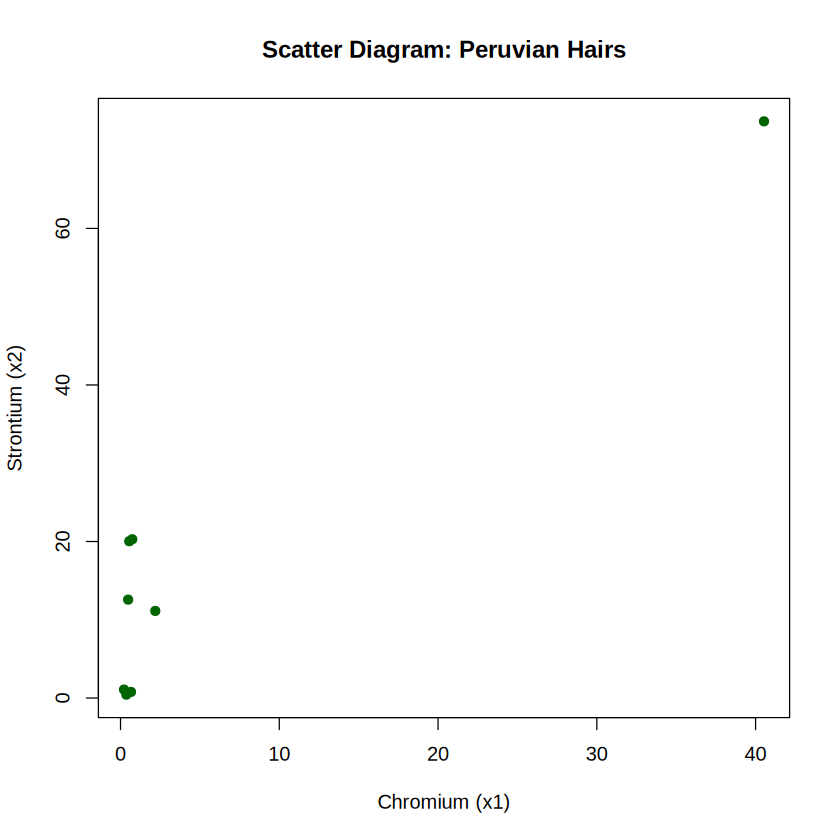

In [112]:
d2 <- mahalanobis(clean_data, xbar_new, S_new)
qqplot(qchisq(ppoints(n_new), df = p), d2,
       main = "Chi-Square Q-Q Plot", xlab="Chi-Square Quantile", ylab="Mahalanobis Distance")
abline(a = 0, b = 1, col="red", lwd=2)

plot(clean_data$cr, clean_data$st,
     main="Scatter Diagram: Peruvian Hairs",
     xlab="Chromium (x1)", ylab="Strontium (x2)", pch=19, col="darkgreen")

After outlier removal, the new T^2 for [.30, 10] is 1.381806 and the new critical value is 8.081043. Since T^2 is still below critical value, so [0.30,10]' remains to be a plausible value for the population mean vector.

Q-Q Plot Assessment: The new plot shows that the points align slightly better with the red reference line than in the previous graph. However, it can still be seen that the point in the extreme upper tail deviates upward, which indicates that the data is still heavy-tailed and the assumption of bivariate normality is still questionable.   

Scatter Diagram: The new scatter plot shows that while one extreme outlier was removed, the data still does not form the expected elliptical cloud of a bivariate normal distribution. The remaining points are still with one extreme point still visible far away from the cluster.   

This means that bivariate normal distrubtion is still not satisfied, and the previous conclusion of [0.30, 10]' being a plausible value should not be treated as completely accurate or reliable.

# **4**

In [113]:
x1 = c(1232, 1115, 2205, 1897, 1932, 1612, 1598, 1804, 1752, 2067,
         2365, 1646, 1579, 1880, 1773, 1712, 1932, 1820, 1900, 2426,
         1558, 1470, 1858, 1587, 2208, 1487, 2206, 2332, 2540, 2322)

x2 = c(4175, 6652, 7612, 10914, 10850, 7627, 6954, 8365, 9469, 6410,
         10327, 7320, 8196, 9709, 10370, 7749, 6818, 9307, 6457, 10102,
         7414, 7556, 7833, 8309, 9559, 6255, 10723, 5430, 12090, 10072)

lumber_data <- data.frame(
  stiffness = x1,
  bending_strength = x2
)

n <- nrow(lumber_data)
p <- ncol(lumber_data)
xbar <- colMeans(lumber_data)
S <- cov(lumber_data)

lumber_data

cat("Column Means (X-bar):\n")
xbar

cat("Covariance (S):\n")
S

stiffness,bending_strength
<dbl>,<dbl>
1232,4175
1115,6652
2205,7612
1897,10914
1932,10850
1612,7627
1598,6954
1804,8365
1752,9469


Column Means (X-bar):


stiffness bending_strength 
        1860.500         8354.133

Covariance (S):


,stiffness,bending_strength
stiffness,124054.7,361620.4
bending_strength,361620.4,3486333.2


## **4.a**

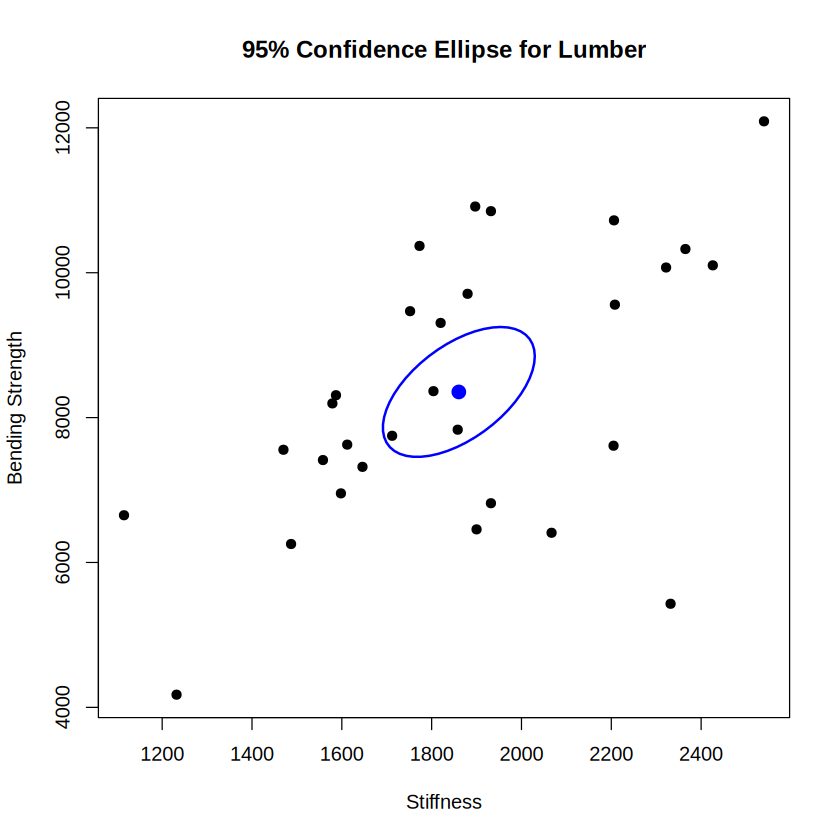

In [114]:
F_crit <- qf(0.95, p, n - p)
crit_val <- ((n - 1) * p / (n - p)) * F_crit

plot(lumber_data$stiffness, lumber_data$bending_strength, xlab="Stiffness", ylab="Bending Strength",
     pch=19, main="95% Confidence Ellipse for Lumber")

ellipse(xbar, S/n, radius=sqrt(crit_val), col="blue")

## **4.b**

T2 for [2000, 10000]: 23.64778 
Critical value: 6.91937 


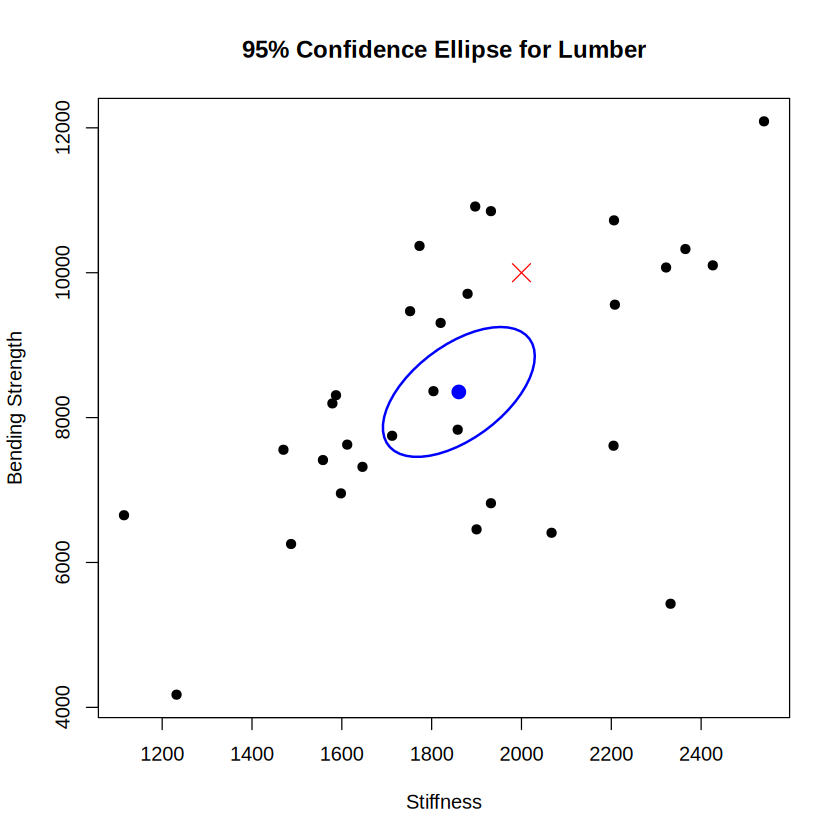

In [115]:
mu <- c(2000, 10000)
T2 <- n * t(xbar - mu) %*% solve(S) %*% (xbar - mu)

plot(lumber_data$stiffness, lumber_data$bending_strength, xlab="Stiffness", ylab="Bending Strength",
     pch=19, main="95% Confidence Ellipse for Lumber")
ellipse(xbar, S/n, radius=sqrt(crit_val), col="blue")
points(2000, 10000, col="red", pch=4, cex=2)

cat("T2 for [2000, 10000]:", T2, "\n")
cat("Critical value:", crit_val, "\n")

The proposed typical population mean vector is [2000,10000]' which has T^2 = 23.64778. Meanwhile the critical value for the 95% confidence region is 6.91937. Since 23.64778>6.91937, this means that [2000,10000]' lies outside the 95% confidence region. Therefore [2000,10000]' is not consistent with the observed sample at the 95% confidence level.

The graph confirms this as the [2000,10000]' point (indicated by the red x), lies outside the confidence ellipse.

## **4.c**

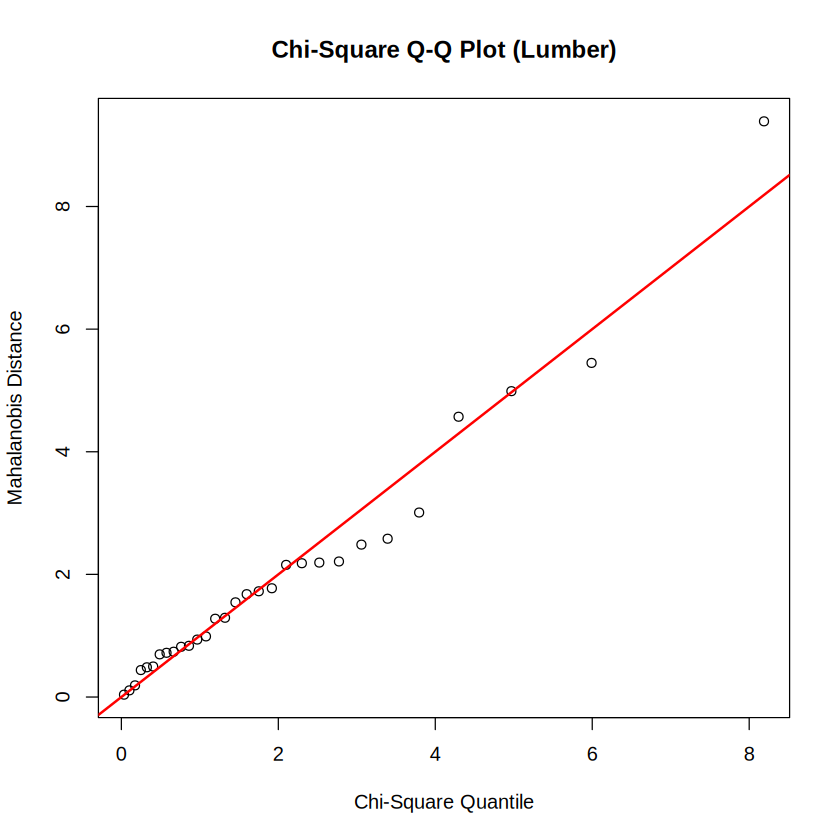

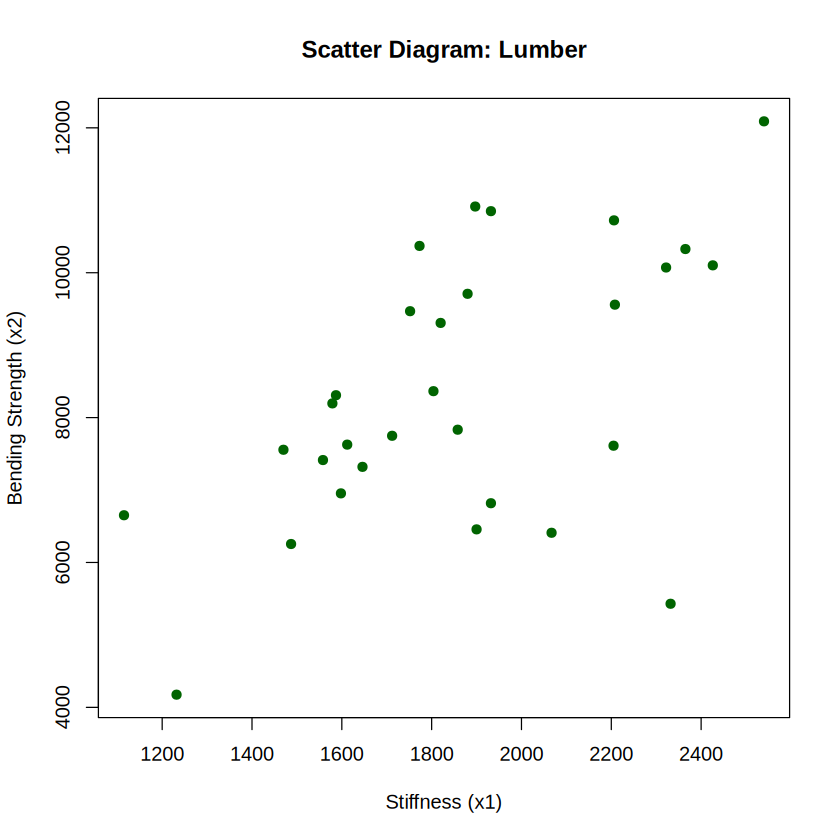

In [116]:
d2_lumber <- mahalanobis(lumber_data, xbar, S)
qqplot(qchisq(ppoints(n), df = p), d2_lumber,
       main = "Chi-Square Q-Q Plot (Lumber)", xlab="Chi-Square Quantile", ylab="Mahalanobis Distance")
abline(a = 0, b = 1, col="red", lwd=2)

plot(lumber_data$stiffness, lumber_data$bending_strength,
     main="Scatter Diagram: Lumber",
     xlab="Stiffness (x1)", ylab="Bending Strength (x2)", pch=19, col="darkgreen")

Q-Q Plot: The plotted points align very closely to the red reference line. This shows that the quantiles of the sample distances follow the theoretical quantiles of the Chi-Square distribution, meaning that there is strong evidence that the underlying population is multivariate normal.  

Scatter Diagram: The scatter plot of stiffness versus bending strength shows a scattered, upward-sloping elliptical cloud of points. Unlike the previous dataset, there iss no extreme outlier that skews the data.

Thus it can be said that, the bivariate normal distribution is a viable population model for the lumber dataset.